In [1]:
import pandas as pd

In [51]:
# Charger le dataset
df = pd.read_csv("spam mail.csv")  
df.head()


,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [52]:
df = df.rename(columns={
    'Category': 'label',
    'Masseges': 'text'
})


In [53]:
print(df.isnull().sum())

label    0
text     0
dtype: int64


#### Encodage de la variable cible (label)

- spam → 1

- ham → 0

In [54]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [41]:
print(df['label'].value_counts())

label
0    4825
1     747
Name: count, dtype: int64


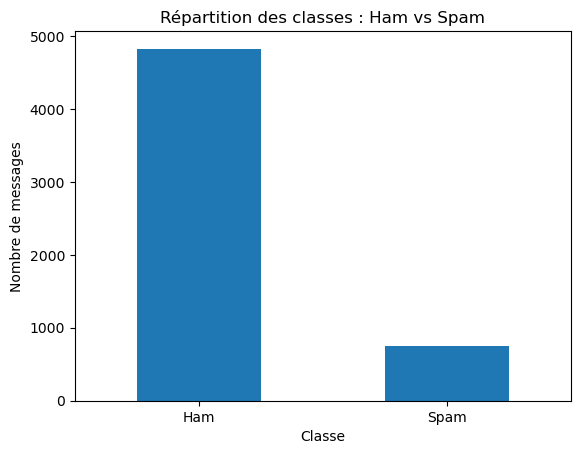

In [42]:
import matplotlib.pyplot as plt

counts = df['label'].value_counts()

plt.figure()
counts.plot(kind='bar')
plt.xlabel("Classe")
plt.ylabel("Nombre de messages")
plt.title("Répartition des classes : Ham vs Spam")
plt.xticks([0,1], ['Ham', 'Spam'], rotation=0)
plt.show()


#### Nettoyage du Texte

In [55]:
import re
import nltk
from nltk.corpus import stopwords
from nltk import PorterStemmer as Stemmer 

nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /home/amira/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [56]:
def clean_text(text):
    # Passage en minuscules
    text = text.lower()
    
    # Suppression des chiffres
    text = re.sub(r'\d+', '', text)
    
    # Suppression de la ponctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Suppression des stopwords
    stop_words = set(stopwords.words('english'))
    text = [t for t in text.split() if t not in stop_words]
    
    st= Stemmer()     
    text = [st.stem(t) for t in text]

    text=' '.join(text)


    return text


In [57]:
df['clean_text'] = df['text'].apply(clean_text)

# Comparaison avant / après
df[['text', 'clean_text']].head()


,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goe usf live around though


In [58]:
X = df['clean_text']   
y = df['label']        


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42 )

tfidf = TfidfVectorizer(analyzer=clean_text,ngram_range = (1, 2))

# Apprendre le vocabulaire + transformer le train
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformer le test (SANS fit)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_train_tfidf)



/home/amira/.local/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:533: UserWarning: The parameter 'ngram_range' will not be used since 'analyzer' is callable'
  warnings.warn(


(4457, 42)
  (0, 10)	0.2506644879058122
  (0, 14)	0.39599184231078216
  (0, 0)	0.5750728848893153
  (0, 3)	0.1327125939499851
  (0, 16)	0.24464327634602565
  (0, 2)	0.24030505490965118
  (0, 21)	0.1633546644084634
  (0, 20)	0.0944584856212826
  (0, 13)	0.2682104934981568
  (0, 4)	0.20448918892207038
  (0, 9)	0.19889863657261506
  (0, 6)	0.15553438224565058
  (0, 12)	0.23721265939637648
  (0, 26)	0.1335575300717764
  (0, 7)	0.14053703795015904
  (0, 15)	0.0864285154330934
  (1, 10)	0.16290962301013617
  (1, 14)	0.19301960845620145
  (1, 0)	0.4671827851611759
  (1, 3)	0.3450055303759371
  (1, 16)	0.15899637102352976
  (1, 2)	0.20823588390907244
  (1, 21)	0.1592490046240393
  (1, 20)	0.3069480725258073
  (1, 13)	0.11620864406759117
  :	:
  (4454, 19)	0.5419797014360576
  (4454, 17)	0.11637298158284878
  (4454, 5)	0.10371171332283935
  (4455, 10)	0.15552624194019235
  (4455, 0)	0.4014082371529042
  (4455, 16)	0.45537103844159355
  (4455, 21)	0.30406305980282244
  (4455, 20)	0.1758219532105

In [60]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


#### Evaluation sur les données train

In [61]:
y_pred_train = model.predict(X_train_tfidf)
print("Accuracy :", accuracy_score(y_train, y_pred_train))
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train))

Accuracy : 0.8667264976441552
[[3860    0]
 [ 594    3]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      3860
           1       1.00      0.01      0.01       597

    accuracy                           0.87      4457
   macro avg       0.93      0.50      0.47      4457
weighted avg       0.88      0.87      0.81      4457



#### Evaluation sur les données test

In [62]:
y_pred = model.predict(X_test_tfidf)


In [63]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy : 0.8654708520179372
[[965   0]
 [150   0]]
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       965
           1       0.00      0.00      0.00       150

    accuracy                           0.87      1115
   macro avg       0.43      0.50      0.46      1115
weighted avg       0.75      0.87      0.80      1115



/home/amira/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/amira/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/amira/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])



#### 1️ matrice de confusion

| Réel \ Prédit | Ham (0) | Spam (1) |
| ------------- | ------- | -------- |
| **Ham (0)**   | 965     | 0        |
| **Spam (1)**  | 150     | 0        |

👉 **Interprétation** :

* Le modèle prédit **TOUS les messages comme non-spam (ham)**
* Aucun message n’est prédit comme spam ❌



#### 2️ Pourquoi l’accuracy est élevée (≈ 86 %) ?

```text
Accuracy : 0.865
```

📌 L’accuracy mesure :

> Nombre de prédictions correctes / nombre total

Ici :

* La majorité des messages sont **non-spam**
* En prédisant toujours **ham**, le modèle est souvent correct

👉 **Accuracy trompeuse** dans un dataset déséquilibré ⚠️



#### 3️ Analyse par classe

### 🔹 Classe 0 (Ham)

```text
Precision = 0.87
Recall = 1.00
F1-score = 0.93
```

* **Recall = 1.00**
  → Tous les messages non-spam ont été correctement détectés
* Bonne performance sur la classe majoritaire



**🔴 Classe 1 (Spam)**
```text
Precision = 0.00
Recall = 0.00
F1-score = 0.00
```

* **Recall = 0.00**
  → Aucun spam n’a été détecté
* **Precision = 0.00**
  → Le modèle ne prédit jamais la classe spam

❌ Le modèle est **inutile pour détecter le spam**



#### 4️ Pourquoi ce problème arrive ?

### 🔥 Cause principale : **déséquilibre des classes**

* Ham ≫ Spam
* Le modèle apprend que prédire toujours "ham" minimise l’erreur

📌 C’est très fréquent en spam detection.



#### 5️ Avertissement sklearn (warning)

```text
UndefinedMetricWarning: Precision is ill-defined
```

👉 Ce message apparaît parce que :

* Le modèle **n’a jamais prédit la classe 1**
* Donc la precision pour spam est impossible à calculer



#### 6️ Macro vs Weighted Average

 **🔹 Macro average**

```text
macro avg F1 = 0.46
```

* Moyenne simple entre classes
* Révèle la **mauvaise performance globale**

**🔹 Weighted average**

```text
weighted avg F1 = 0.80
```

* Pondéré par le nombre d’exemples
* Dominé par la classe ham

👉 **Macro avg est plus honnête ici**



#### 7️ Conclusion 

> Bien que l’accuracy soit relativement élevée (86 %), le modèle ne détecte aucun message spam. Cette performance est due au déséquilibre des classes. Les métriques precision, recall et F1-score montrent que le modèle est inefficace pour la classe minoritaire (spam). L’accuracy seule n’est donc pas suffisante pour évaluer un modèle de détection de spam.






### Solution 1 : **Logistic Regression avec pondération**

**class_weight='balanced'** : donne plus d’importance aux spam



In [73]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(class_weight='balanced',max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [74]:
y_pred_lr = model_lr.predict(X_test_tfidf)

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy : 0.8789237668161435
[[844 121]
 [ 14 136]]
              precision    recall  f1-score   support

           0       0.98      0.87      0.93       965
           1       0.53      0.91      0.67       150

    accuracy                           0.88      1115
   macro avg       0.76      0.89      0.80      1115
weighted avg       0.92      0.88      0.89      1115



### Solution 2 : **Suréchantillonnage de la classe minoritaire (spam)** -->> Augmente artificiellement le nombre de spam

SMOTE ne récupère pas de messages réels.

Mais crée de nouveaux vecteurs synthétiques en combinant les caractéristiques des spams existants dans l’**espace TF-IDF.**

Pour chaque spam existant, il choisit des voisins et crée un nouveau vecteur “entre eux”.

 Exemple simplifié (en 2D) :

- Spam1 → (0.1, 0.7)

- Spam2 → (0.3, 0.9)

--> Nouveau spam synthétique → (0.2, 0.8)

On n’a pas le texte exact correspondant à ce vecteur:  C’est uniquement pour l’entraînement du modèle.

#### **smote.fit_resample(X_train_tfidf, y_train)**

**fit_resample()** fait deux choses :

* fit → analyse les données pour comprendre la distribution des classes

* resample → génère de nouveaux exemples synthetiques pour la classe minoritaire

Entrées :

* X_train_tfidf → tes messages convertis en vecteurs TF-IDF (entraînement)

* y_train → les labels correspondants (0=ham, 1=spam)

Sorties :

* X_train_res → nouvelle matrice d’entraînement équilibrée, avec plus de spams

* y_train_res → labels correspondants

In [ ]:
!pip install imbalanced-learn


In [70]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Appliquer SMOTE sur X_train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

# 2. Entraîner le modèle sur les données rééchantillonnées
model =LogisticRegression(max_iter=1000)
model.fit(X_train_res, y_train_res)

# 3. Prédire sur X_test (inchangé)
y_pred = model.predict(X_test_tfidf)

# 4. Évaluer
print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.8896860986547085
[[857 108]
 [ 15 135]]
              precision    recall  f1-score   support

           0       0.98      0.89      0.93       965
           1       0.56      0.90      0.69       150

    accuracy                           0.89      1115
   macro avg       0.77      0.89      0.81      1115
weighted avg       0.93      0.89      0.90      1115




```python
LogisticRegression(max_iter=1000)
```

* `max_iter` = **nombre maximal d’itérations** autorisées pour l’algorithme d’optimisation.

 À chaque itération :

* le modèle ajuste ses coefficients
* se rapproche du minimum de la fonction de coût

---

#### Pourquoi c’est nécessaire avec TF-IDF ?

* TF-IDF crée :

  * **beaucoup de variables** (milliers de mots)
  * une matrice **sparse et de grande dimension**
* La convergence est donc **plus lente**

📌 Si `max_iter` est trop petit :

* l’algorithme s’arrête **avant d’avoir convergé**
* sklearn affiche souvent un **warning de non-convergence**

Par défaut :

```python
max_iter = 100
```
* Souvent insuffisant pour :

  * texte
  * TF-IDF
  * classes déséquilibrées

Tu peux obtenir :

```
ConvergenceWarning: lbfgs failed to converge
```



In [68]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Appliquer SMOTE sur X_train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_tfidf, y_train)

# 2. Entraîner le modèle sur les données rééchantillonnées
model2 = MultinomialNB()
model2.fit(X_train_res, y_train_res)

# 3. Prédire sur X_test (inchangé)
y_pred = model2.predict(X_test_tfidf)

# 4. Évaluer
print("Accuracy :", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy : 0.8125560538116592
[[780 185]
 [ 24 126]]
              precision    recall  f1-score   support

           0       0.97      0.81      0.88       965
           1       0.41      0.84      0.55       150

    accuracy                           0.81      1115
   macro avg       0.69      0.82      0.71      1115
weighted avg       0.89      0.81      0.84      1115



In [50]:
print(X_train_res.shape)
print(y_train_res.shape)


(7720, 42)
(7720,)



La régression logistique apprend en :

* Faisant une prédiction (probabilité spam)

* Calculant une erreur

* Ajustant les poids pour réduire cette erreur

👉 Cette erreur est mesurée par une fonction appelée log loss.

Sans `class_weight`, la **Logistic Regression** cherche à : **minimiser le nombre total d’erreurs**

⚠️ **Toutes les erreurs ont le même poids.**

#### **Ce que voit réellement le modèle**

Dans notre dataset :  **Ham ≫ Spam**

👉 Donc :

* Se tromper sur **1 ham** = 1 erreur
* Se tromper sur **1 spam** = 1 erreur

Mais : Il y a **beaucoup plus de ham**

#### **Raisonnement implicite du modèle**

Le modèle “apprend” que :

> « Si je prédis **ham** très souvent, je fais peu d’erreurs »

Exemple extrême :

* Prédire **toujours ham**
* Erreurs = nombre de spam seulement
* Accuracy élevée

-->  **Mathématiquement**, c’est une bonne solution sans pondération.

Parce que :

* Les spams sont rares
* Leur impact sur la perte totale est faible
* Le modèle **n’est pas pénalisé fortement** quand il les rate

Donc il préfère :

* Bien classer les ham
* Ignorer la classe minoritaire

#### **Analogie**

Imagine un examen avec :

* 90 questions faciles (ham)
* 10 questions difficiles (spam)

Si chaque question vaut 1 point :

* Tu passes l’examen même en ignorant les difficiles

👉 Le modèle fait exactement ça.



#### **Que change `class_weight` ?**

Avec `class_weight='balanced'` :

* Une erreur sur spam = **plusieurs erreurs ham**
* Ignorer le spam devient **coûteux**

👉 Le modèle est obligé d’en tenir compte.

👉 Ce paramètre :

    - donne plus d’importance à la classe minoritaire (spam)

    - pénalise davantage les erreurs sur spam que sur ham

📌 Les poids sont calculés automatiquement :

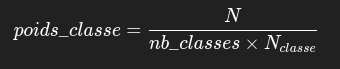

    Plus une classe est rare → plus son poids est élevé

Sans class_weight (simplifié) :

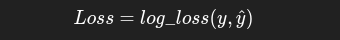

Avec class_weight :

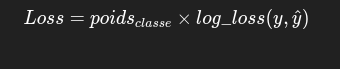

📌 Donc :

Erreur sur spam → log loss × grand poids

Erreur sur ham → log loss × petit poids

👉 Le modèle modifie ses paramètres pour réduire **surtout les erreurs sur spam.**



